In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Outliers

In [2]:
x = np.array([0.875, 0.863, 0.876, 0.868, 0.771, 0.881, 0.878, 0.869, 0.866])
df = pd.DataFrame(x,
                  columns = ['value'])
print(df)

   value
0  0.875
1  0.863
2  0.876
3  0.868
4  0.771
5  0.881
6  0.878
7  0.869
8  0.866


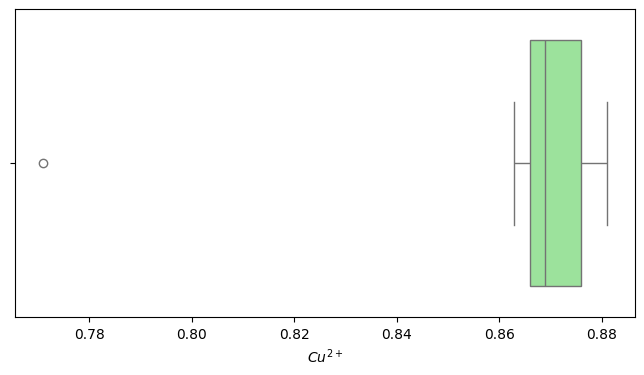

In [3]:
plt.figure(figsize=(8, 4))
sns.boxplot(data = df,
            x = 'value',
            color = 'lightgreen')
plt.xlabel('$Cu^{2+}$')
plt.show()

#### Grubbs

In [5]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 86.1 MB/s  0:00:00 91.3 MB/s eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
from scipy.stats import shapiro, median_abs_deviation

# Normality test (SW)
print("Shapiro-Wilk Test:", np.round(shapiro(x), 5))

Shapiro-Wilk Test: [5.5843e-01 3.0000e-05]


In [7]:
# Hampel filter
median_x = np.median(x)
mad_x = median_abs_deviation(x, scale = 'normal')
hampel_limits = np.round((median_x - 3 * mad_x, median_x + 3 * mad_x), 3)
print("Hampel Filter Limits:", hampel_limits)

Hampel Filter Limits: [0.842 0.896]


In [8]:
! pip install outliers outlier_utils

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for outliers: filename=outliers-0.1-py3-none-any.whl size=1987 sha256=83af4a8f202941a47f6984142eb82dad07d07f482a4fac8acd2f007fa0f10227
  Stored in directory: /Users/mikolaj.mlodzikowski/Library/Caches/pip/wheels/57/82/ca/12f3c9193036c42205f3c578bd8aa33873b970ee9364161b05
Successfully built outliers
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [outliers]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
from outliers import smirnov_grubbs as grubbs

print("Data after performing Grubb's test:")
grubbs.test(x, alpha = 0.05)

Data after performing Grubb's test:


array([0.875, 0.863, 0.876, 0.868, 0.881, 0.878, 0.869, 0.866])

### Isolation forest

In [12]:
from sklearn.ensemble import IsolationForest

# Model using Isolation Forest
model_iso = IsolationForest(n_estimators = 1000)
model_iso.fit(df)

# Prediction
pred = model_iso.decision_function(df)
print(pred)

# Analyzing predictions
# The lower the score, the more abnormal.
# Scores are shifted such that 0 indicates an inlier.

# Display point with the lowest outlier score
min_outlier_index = np.argmin(pred)
print('Point with lowest outlier score:', x[min_outlier_index])

[ 0.08935583 -0.0098607   0.10332501  0.1034398  -0.29269163 -0.02138205
  0.06963351  0.09374462  0.07106059]
Point with lowest outlier score: 0.771


# Exercice 1 (15 min)

The dataset 'trees' contains information about the diameter, height, and wood volume of 31 felled cherry trees. Check for outliers using Isolation Forests. Draw a scatter plot where the X-axis represents the diameter, the Y-axis represents the height, and the color of the point depends on whether it is an outlier or not.

1. Ryan, T. A., Joiner, B. L. and Ryan, B. F. (1976) The Minitab Student Handbook. Duxbury Press.
2. Atkinson, A. C. (1985) Plots, Transformations and Regression. Oxford University Press.

   Diameter  Height  Volume  iso_scores  iso_outlierness
0       8.3      70    10.3          -1        -0.043759
1       8.6      65    10.3          -1        -0.034628
2       8.8      63    10.2          -1        -0.073756
3      10.5      72    16.4           1         0.052170
4      10.7      81    18.8           1         0.074376


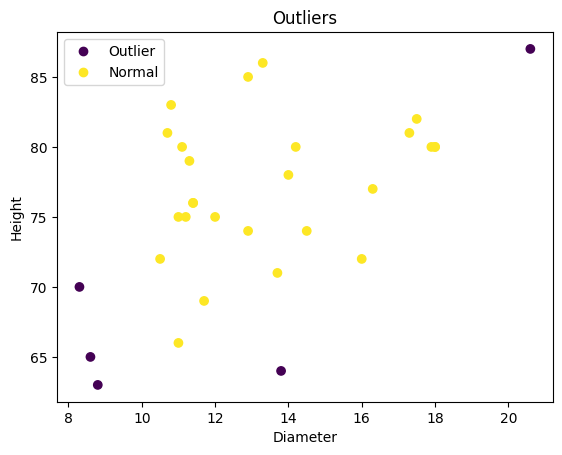

In [92]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
df = pd.read_csv('../data/trees.csv')

iso_forest = IsolationForest(
    contamination=0.15, # ustawienie maksymalnej liczby anomalii na 15%
    n_estimators=2000, # liczba drzew w lesie (liczba prób)
    max_features=0.67, # użycie dwóch z trzech cech
    random_state=42
)
iso_scores = iso_forest.fit_predict(df)
df = df.assign(
    iso_scores=iso_scores,
    iso_outlierness=iso_forest.decision_function(df)
)

print(df.head())

# Znalezienie i opisanie najbardziej odstających punktów
most_outlying = np.argmin(df['iso_outlierness'])  # Najbardziej odstający według Isolation Forest
df.iloc[most_outlying]
scatter = plt.scatter(
    df['Diameter'],
    df['Height'],
    c = df['iso_scores']
)
plt.xlabel('Diameter')
plt.ylabel('Height')
plt.title('Outliers')
plt.legend(
    handles = scatter.legend_elements()[0],
    labels = ['Outlier', 'Normal']
)
plt.show()

# Missing data

In [16]:
# Data frame with missing data
df = pd.DataFrame({
    'col1': [1, 2, 3, None],  # None represents NA in Python
    'col2': ['this', None, 'is', 'text'],
    'col3': [True, False, True, True],
    'col4': [2.5, 4.2, 3.2, None]
})

# Identify NAs
na_mask = df.isna()  # This returns a DataFrame of the same shape as df with True where values are NA
print(na_mask)

# Identify count of NAs in data frame
total_nas = na_mask.sum().sum()  # Sum twice: first across columns, then across the result
print("Total NAs in DataFrame:", total_nas)

# Identify count of NAs in each column of data frame
nas_per_column = na_mask.sum()
print("NAs in each column:\n", nas_per_column)

    col1   col2   col3   col4
0  False  False  False  False
1  False   True  False  False
2  False  False  False  False
3   True  False  False   True
Total NAs in DataFrame: 3
NAs in each column:
 col1    1
col2    1
col3    0
col4    1
dtype: int64


In [17]:
df.value_counts(dropna = False)

col1  col2  col3   col4
1.0   this  True   2.5     1
2.0   NaN   False  4.2     1
3.0   is    True   3.2     1
NaN   text  True   NaN     1
Name: count, dtype: int64

In [18]:
# Remove missing data (rows with missing data)
df_cleaned = df.dropna()

# Recode missing values
df_recode = df.fillna({
    'col1': 1,
    'col2': 'Missing',
    'col3': False,
    'col4': 2
})

# Replace missing values using the next or previous entry (forward fill and backward fill)
df_filled = df.fillna(method = 'ffill').fillna(method = 'bfill')

# Replace missing values using mean or median
df['col1'].fillna(df['col1'].mean(), inplace = True)
df['col4'].fillna(df['col4'].median(), inplace = True)

# Displaying outputs
print("DataFrame after removing rows with missing data:\n", df_cleaned)
print("\nDataFrame after recoding missing values:\n", df_recode)
print("\nDataFrame after filling missing values with next or previous entries:\n", df_filled)
print("\nDataFrame after replacing missing values with mean/median:\n", df)

DataFrame after removing rows with missing data:
    col1  col2  col3  col4
0   1.0  this  True   2.5
2   3.0    is  True   3.2

DataFrame after recoding missing values:
    col1     col2   col3  col4
0   1.0     this   True   2.5
1   2.0  Missing  False   4.2
2   3.0       is   True   3.2
3   1.0     text   True   2.0

DataFrame after filling missing values with next or previous entries:
    col1  col2   col3  col4
0   1.0  this   True   2.5
1   2.0  this  False   4.2
2   3.0    is   True   3.2
3   3.0  text   True   3.2

DataFrame after replacing missing values with mean/median:
    col1  col2   col3  col4
0   1.0  this   True   2.5
1   2.0  None  False   4.2
2   3.0    is   True   3.2
3   2.0  text   True   3.2


In [19]:
# Daily air quality measurements in New York, May to September 1973.
# Chambers, J. M., Cleveland, W. S., Kleiner, B. and Tukey, P. A. (1983) Graphical Methods for Data Analysis. Belmont, CA: Wadsworth.
airquality = pd.read_csv('airquality.csv', na_values = ['NA'])
airquality.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [20]:
print(airquality.describe())
print(airquality.info())

            Ozone     Solar.R        Wind        Temp       Month         Day
count  116.000000  146.000000  153.000000  153.000000  153.000000  153.000000
mean    42.129310  185.931507    9.957516   77.882353    6.993464   15.803922
std     32.987885   90.058422    3.523001    9.465270    1.416522    8.864520
min      1.000000    7.000000    1.700000   56.000000    5.000000    1.000000
25%     18.000000  115.750000    7.400000   72.000000    6.000000    8.000000
50%     31.500000  205.000000    9.700000   79.000000    7.000000   16.000000
75%     63.250000  258.750000   11.500000   85.000000    8.000000   23.000000
max    168.000000  334.000000   20.700000   97.000000    9.000000   31.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3  

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
train_df = airquality.dropna().drop(columns = ['Solar.R'])
model = LinearRegression()
model.fit(train_df.drop(columns=['Ozone']), train_df['Ozone']);

In [23]:
# Predict missing Ozone values using the model
airquality['Prediction'] = model.predict(airquality.drop(columns=['Ozone', 'Solar.R']))

In [24]:
# Imputation
airquality['Ozone'] = np.where(airquality['Ozone'].isna(),
                               airquality['Prediction'],
                               airquality['Ozone'])

# Clean up the DataFrame
airquality.drop(columns = ['Prediction'], inplace = True)

In [ ]:
print(airquality.describe())
print(airquality.info())

In [30]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

airquality = pd.read_csv('airquality.csv', na_values = ['NA'])

# Multiple imputation using IterativeImputer (MICE)
imputer = IterativeImputer(max_iter = 10)
airquality_imputed = imputer.fit_transform(airquality)

In [31]:
# Convert the imputed numpy array back to a pandas DataFrame
airquality_imputed = pd.DataFrame(airquality_imputed)

# Show the imputed DataFrame
print(airquality_imputed.head())

           0           1     2     3    4    5
0  41.000000  190.000000   7.4  67.0  5.0  1.0
1  36.000000  118.000000   8.0  72.0  5.0  2.0
2  12.000000  149.000000  12.6  74.0  5.0  3.0
3  18.000000  313.000000  11.5  62.0  5.0  4.0
4 -12.272303  141.910042  14.3  56.0  5.0  5.0


# Encoding

In [ ]:
!pip install category_encoders

In [33]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from category_encoders import TargetEncoder

# The counts of insects in agricultural experimental units treated with different insecticides.
# Beall, G., (1942) The Transformation of data from entomological field experiments, Biometrika, 29, 243–262.
# McNeil, D. (1977) Interactive Data Analysis. New York: Wiley.

df = pd.read_csv('InsectSprays.csv')
print(df.head())

# Display frequency of each category
print(df['spray'].value_counts())

# Label encoding
label_encoder = LabelEncoder()
df['spray_label'] = label_encoder.fit_transform(df['spray'])

# One hot encoding
onehot_encoder = OneHotEncoder(sparse = False)
onehot_encoded = onehot_encoder.fit_transform(df[['spray']])
df_onehot = pd.DataFrame(onehot_encoded,
                         columns = onehot_encoder.get_feature_names_out(['spray']))

# Dummy encoding
dummy_encoder = OneHotEncoder(sparse = False, drop = 'first')
dummy_encoded = dummy_encoder.fit_transform(df[['spray']])
df_dummy = pd.DataFrame(dummy_encoded,
                         columns = dummy_encoder.get_feature_names_out(['spray']))

# Target encoding
target_encoder = TargetEncoder(cols = ['spray'])
df['spray_target'] = target_encoder.fit_transform(df['spray'],
                                                  df['count'])

df.groupby('spray')['count'].mean()


   count spray
0     10     A
1      7     A
2     20     A
3     14     A
4     14     A
spray
A    12
B    12
C    12
D    12
E    12
F    12
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


spray
A    14.500000
B    15.333333
C     2.083333
D     4.916667
E     3.500000
F    16.666667
Name: count, dtype: float64

In [34]:
# Print the dataframes to show encoded results
print("Label Encoded:\n", df)
print("One Hot Encoded:\n", df_onehot)
print("Dummy Encoded:\n", df_dummy)
print("Target Encoded:\n", df)

Label Encoded:
     count spray  spray_label  spray_target
0      10     A            0     11.050128
1       7     A            0     11.050128
2      20     A            0     11.050128
3      14     A            0     11.050128
4      14     A            0     11.050128
..    ...   ...          ...           ...
67     10     F            5     11.721850
68     26     F            5     11.721850
69     26     F            5     11.721850
70     24     F            5     11.721850
71     13     F            5     11.721850

[72 rows x 4 columns]
One Hot Encoded:
     spray_A  spray_B  spray_C  spray_D  spray_E  spray_F
0       1.0      0.0      0.0      0.0      0.0      0.0
1       1.0      0.0      0.0      0.0      0.0      0.0
2       1.0      0.0      0.0      0.0      0.0      0.0
3       1.0      0.0      0.0      0.0      0.0      0.0
4       1.0      0.0      0.0      0.0      0.0      0.0
..      ...      ...      ...      ...      ...      ...
67      0.0      0.0      0.